# 16.2.1 共同 Lyapunov 矩阵与顶点条件

## 学习目标与先修知识

在给定仿射（affine）矩阵（matrix）集合上用同一个正定（positive definite）矩阵核验导数（derivative）。

先修：16.1 Lyapunov 函数（Lyapunov function）；线性代数（linear algebra）与特征值（eigenvalue）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

系统矩阵随不确定参数（parameter）变化。只测几个随机参数是否足以证明整个区间稳定？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
A0=np.array([[-.4,.1],[0.,-.5]]);A1=np.array([[-.8,.1],[0.,-.5]]);print("两顶点对称部分的最大特征值：",[np.linalg.eigvalsh(A+A.T)[-1] for A in [A0,A1]])

两顶点对称部分的最大特征值： [np.float64(-0.7585786437626905), np.float64(-0.983772233983162)]


## 模型假设

连续系统 $\dot x=A(\alpha)x$，$A(\alpha)=(1-\alpha)A_0+\alpha A_1$，$0\le\alpha\le1$；两状态（state）已归一化，同一个 $P=P^\mathsf T\succ0$ 用于全部候选。输入（input）饱和不在此结论内。

## 数学解释与推导

若 $V=x^\mathsf TPx$ 且 $P\succ0$，则 $\dot V=x^\mathsf T(A^\mathsf TP+PA)x$。对每个顶点有 $A_i^\mathsf TP+PA_i\prec0$，而中间矩阵是两顶点的凸组合，所以同一个 P 使整个仿射区间的对称导数矩阵负定。顶点检查的充分结论依赖“同一个 P”“仿射集合”和“严格不等式”；随机抽样本身不提供此证明。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def common_quadratic(vertices,P):
    matrix=np.asarray(P,dtype=float)
    smallest=float(np.linalg.eigvalsh(matrix)[0])
    margins=[]
    for A in vertices:
        A=np.asarray(A,dtype=float)
        symmetric=A.T@matrix+matrix@A
        margins.append(float(np.linalg.eigvalsh(symmetric)[-1]))
    return [smallest,margins,smallest>0 and all(value<0 for value in margins)]


def affine_vertex(A0,A1,alpha):
    return ((1-alpha)*np.asarray(A0,dtype=float)+alpha*np.asarray(A1,dtype=float)).tolist()

## 对照实验

固定 P，在两个顶点之间逐点改变 α，观察导数矩阵最大特征值与零的距离，并核对两个顶点。

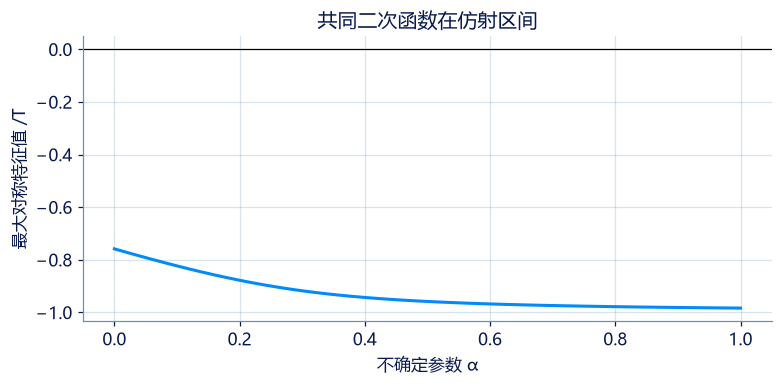

顶点核验： [1.0, [-0.7585786437626905, -0.983772233983162], True]


In [4]:
A0=[[-.4,.1],[0.,-.5]];A1=[[-.8,.1],[0.,-.5]];P=np.eye(2)
fractions=np.linspace(0,1,51);margin=[common_quadratic([affine_vertex(A0,A1,t)],P)[1][0] for t in fractions]
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(fractions,margin,color=BLUE);ax.axhline(0,color="black",lw=.8);ax.set(xlabel="不确定参数 α",ylabel="最大对称特征值 /T",title="共同二次函数在仿射区间");ax.grid(alpha=.25);plt.show()
print("顶点核验：",common_quadratic([A0,A1],P))

## 结果解释

共同 P 在两个顶点都给出严格负定的导数矩阵，凸组合论证把它扩展到整个区间；图中曲线展示区间内的余量变化。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
small,margins,valid=common_quadratic([A0,A1],P)
assert small==1. and valid and max(margins)<0
for t in [0.,.2,.7,1.]:
    matrix=np.asarray(affine_vertex(A0,A1,t));np.testing.assert_allclose(matrix,(1-t)*np.asarray(A0)+t*np.asarray(A1))
print("端点和凸组合恒等式核验通过。")

端点和凸组合恒等式核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：为什么要共同矩阵

两个顶点分别能找到不同的正定（positive definite） P，能直接推出区间内存在同一个共同二次证书吗？

- **A.** 不能；顶点凸组合推导要求同一个 P。
- **B.** 能，因为两个 P 都正定。
- **C.** 能，只要扫描100个参数（parameter）。
- **D.** 可以忽略顶点。

[作答：为什么要共同矩阵](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-common-p)

### 第 2 题 · 单项选择题：顶点法适用范围

顶点导数（derivative）矩阵（matrix）负定的推论依赖什么？

- **A.** 任意非线性参数（parameter）变化也成立。
- **B.** 参数集合是给定凸包且使用同一个 P。
- **C.** 只有随机抽样而无集合定义。
- **D.** 输入（input）已饱和但不写进模型（model）。

[作答：顶点法适用范围](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-vertex-scope)

### 第 3 题 · Python 计算题：共同二次证书的顶点检查

对给定顶点矩阵（matrix）和同一个 P，返回 P 最小特征值（eigenvalue）、各顶点 AᵀP+PA 最大特征值及严格条件是否成立。

**函数与代码模板**

```python
def solve(
    vertices: list[list[list[float]]],
    P: list[list[float]],
) -> list:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `vertices` | `list[list[list[float]]]` | 两个或更多二维顶点矩阵。 | 1/T |
| `P` | `list[list[float]]` | 同一个对称候选矩阵。 | 按状态尺度 |

**返回值**

直接返回 result（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list` | 最小特征值、顶点最大特征值列表、布尔结论。 | 混合 |

**计算规则**

P 最小特征值应为正；逐顶点计算对称矩阵 AᵀP+PA 的最大特征值，均严格小于0才返回 True。

**约束与边界**

- 至少一个二维实矩阵顶点；P 为二维实对称候选矩阵；所有输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| vertices | 两个或更多二维顶点矩阵。 | [[[-1.0, 0.0], [0.0, -2.0]], [[-0.5, 0.0], [0.0, -1.0]]] | 1/T |
| P | 同一个对称候选矩阵。 | [[1.0, 0.0], [0.0, 1.0]] | 按状态尺度 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
vertices = [[[-1.0, 0.0], [0.0, -2.0]],
            [[-0.5, 0.0], [0.0, -1.0]]]
P = [[1.0, 0.0], [0.0, 1.0]]

result = solve(vertices, P)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | 最小特征值、顶点最大特征值列表、布尔结论。 | [1.0, [-2.0, -1.0], True] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, [-2.0, -1.0], True]
```

**样例解释**

P=I 时首顶点导数（derivative）矩阵的特征值为 -2、-4；两个顶点都严格为负。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：共同二次证书的顶点检查](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-common-certificate)

### 第 4 题 · Python 计算题：构造区间内模型

按 A(α)=(1-α)A0+αA1 返回指定参数（parameter）的矩阵（matrix）。

**函数与代码模板**

```python
def solve(
    A0: list[list[float]],
    A1: list[list[float]],
    alpha: float,
) -> list[list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `list[list[float]]` | 区间一端的二维矩阵。 | 1/T |
| `A1` | `list[list[float]]` | 另一端的二维矩阵。 | 1/T |
| `alpha` | `float` | 凸组合权重，范围[0,1]。 | 1 |

**返回值**

直接返回 matrix（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 给定 α 的二维矩阵。 | 1/T |

**计算规则**

逐元素计算 (1-alpha)*A0+alpha*A1。

**约束与边界**

- A0、A1 为二维实矩阵；0≤alpha≤1；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 区间一端的二维矩阵。 | [[-1.0, 0.0], [0.0, -2.0]] | 1/T |
| A1 | 另一端的二维矩阵。 | [[-0.5, 0.0], [0.0, -1.0]] | 1/T |
| alpha | 凸组合权重，范围[0,1]。 | 0.5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = [[-1.0, 0.0], [0.0, -2.0]]
A1 = [[-0.5, 0.0], [0.0, -1.0]]
alpha = 0.5

result = solve(A0, A1, alpha)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | 给定 α 的二维矩阵。 | [[-0.75, 0.0], [0.0, -1.5]] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[-0.75, 0.0], [0.0, -1.5]]
```

**样例解释**

α=0.5 时逐元素取两个端点平均，得到对角项 -0.75 和 -1.5。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：构造区间内模型](http://127.0.0.1:8000/chapters/16-02-%E6%A8%A1%E5%9E%8B%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7%E4%B8%8E%E9%B2%81%E6%A3%92%E6%8E%A7%E5%88%B6/practice/?question=p16-affine-model)

**进一步阅读**

[Boyd 等原著](https://web.stanford.edu/~boyd/lmibook/)提供共同二次 Lyapunov 条件及 LMI 的完整背景。